Набор данных: **Прогнозирование текучести кадров**

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans
from collections import Counter
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

**Подготовка данных**

In [73]:
pd.set_option('display.max_columns', None)     # для отображения всех столбцов датафрейма при выводе
# загружаем данные из файла в переменную dfInit
# файл должен быть разделён запятыми и закодирован в utf-8
dfInit = pd.read_csv('../dataset/dataset.csv', delimiter=',', encoding='utf8')
# создаём копию датафрейма dfInit
# параметр deep для создания глубокой копии (все данные и индексы копируются, независимо от их иерархии)
df = dfInit.copy(deep=True)
# просмотр данных из датафрейма
df = df.iloc[:, 2:12]

In [74]:
genderDict = {"Male" : 0, "Female" : 1}
maritalDict = {"Married" : 0, "Divorced" : 1, "Single" : 2}
departmentDict = {"IT" : 0, "Sales" : 1, "Marketing" : 2, "HR" : 3, "Finance" : 4}
roleDict = {"Manager" : 0, "Assistant" : 1, "Executive" : 2, "Analyst" : 3}
df["Gender"] = df["Gender"].map(lambda elem : genderDict[elem])
df["Marital_Status"] = df["Marital_Status"].map(lambda elem : maritalDict[elem])
df["Department"] = df["Department"].map(lambda elem : departmentDict[elem])
df["Job_Role"] = df["Job_Role"].map(lambda elem : roleDict[elem])
dfCopy = df.copy()
df

,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion
0,1,0,0,0,1,15488,28,15,4,2
1,1,0,1,1,5,13079,28,6,9,1
2,0,0,2,1,1,13744,24,24,14,8
3,1,1,2,0,1,6809,26,10,8,2
4,0,1,2,2,1,10206,52,29,10,1
...,...,...,...,...,...,...,...,...,...,...
995,1,1,3,3,2,4172,76,24,14,3
996,0,2,0,0,4,11007,71,19,6,0
997,1,1,0,2,1,4641,43,25,12,3
998,1,0,3,2,4,19855,92,13,13,0


In [75]:
df = pd.DataFrame(data=StandardScaler().fit_transform(df), columns=df.columns)
df

,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion
0,1.032529,-1.195696,-1.496948,-1.309465,-1.468616,0.810908,-1.208480,0.009345,-0.884958,-0.804387
1,1.032529,-1.195696,-0.784116,-0.428264,1.390004,0.321082,-1.208480,-1.068968,0.365336,-1.138435
2,-0.968496,-1.195696,-0.071283,-0.428264,-1.468616,0.456297,-1.370491,1.087658,1.615630,1.199900
3,1.032529,0.010859,-0.071283,-1.309465,-1.468616,-0.953809,-1.289486,-0.589717,0.115277,-0.804387
4,-0.968496,0.010859,-0.071283,0.452937,-1.468616,-0.263091,-0.236415,1.686721,0.615395,-1.138435
...,...,...,...,...,...,...,...,...,...,...
995,1.032529,0.010859,0.641549,1.334139,-0.753961,-1.489995,0.735651,1.087658,1.615630,-0.470339
996,-0.968496,1.217414,-1.496948,-1.309465,0.675349,-0.100222,0.533138,0.488596,-0.384840,-1.472483
997,1.032529,0.010859,-1.496948,0.452937,-1.468616,-1.394633,-0.600939,1.207471,1.115512,-0.470339
998,1.032529,-1.195696,0.641549,0.452937,0.675349,1.698858,1.383695,-0.230280,1.365571,-1.472483


In [76]:
ax = df.boxplot(column=list(df.columns),figsize=(18,8))
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
display(ax)

<Axes: >

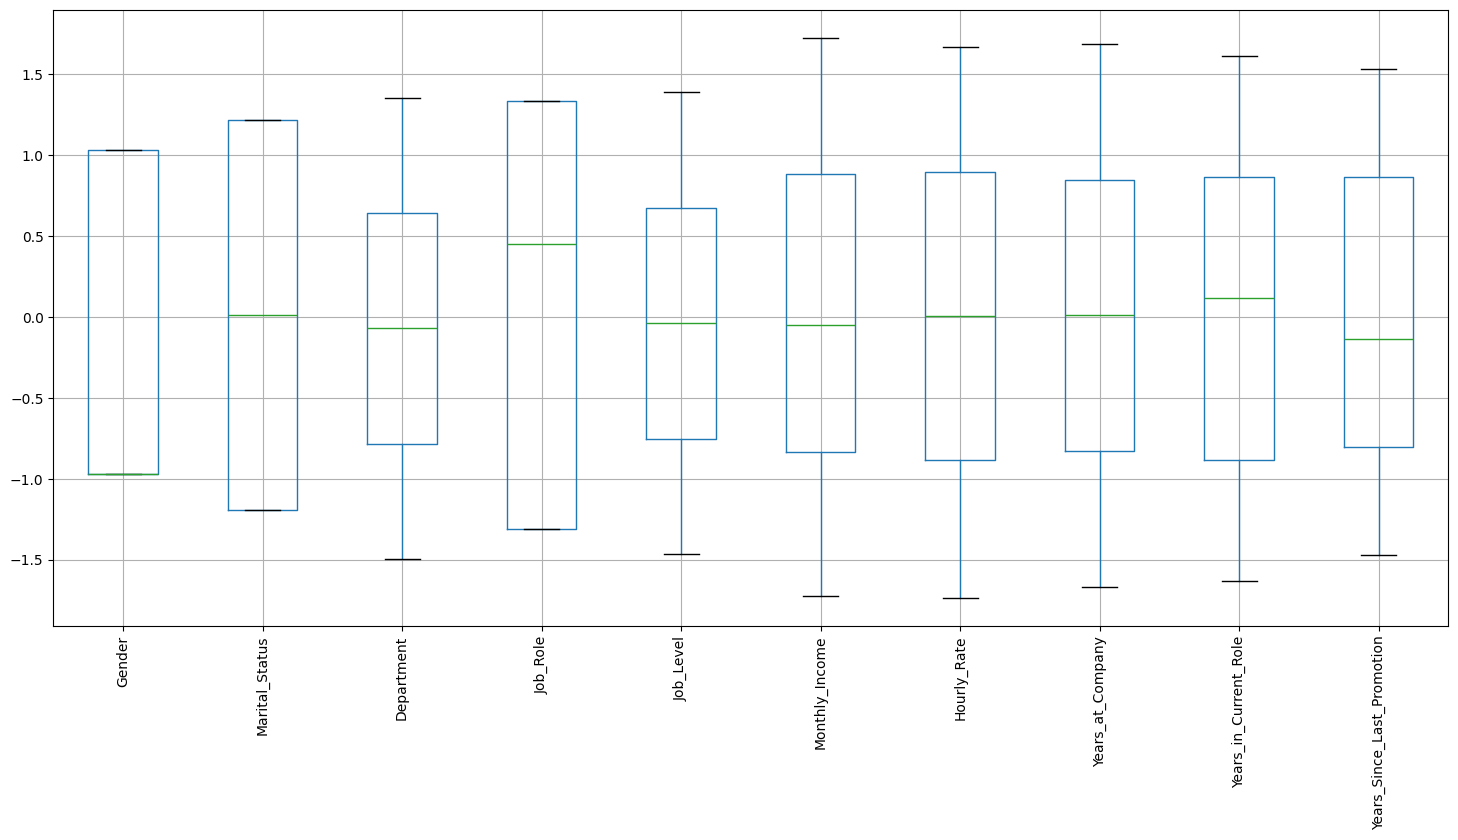

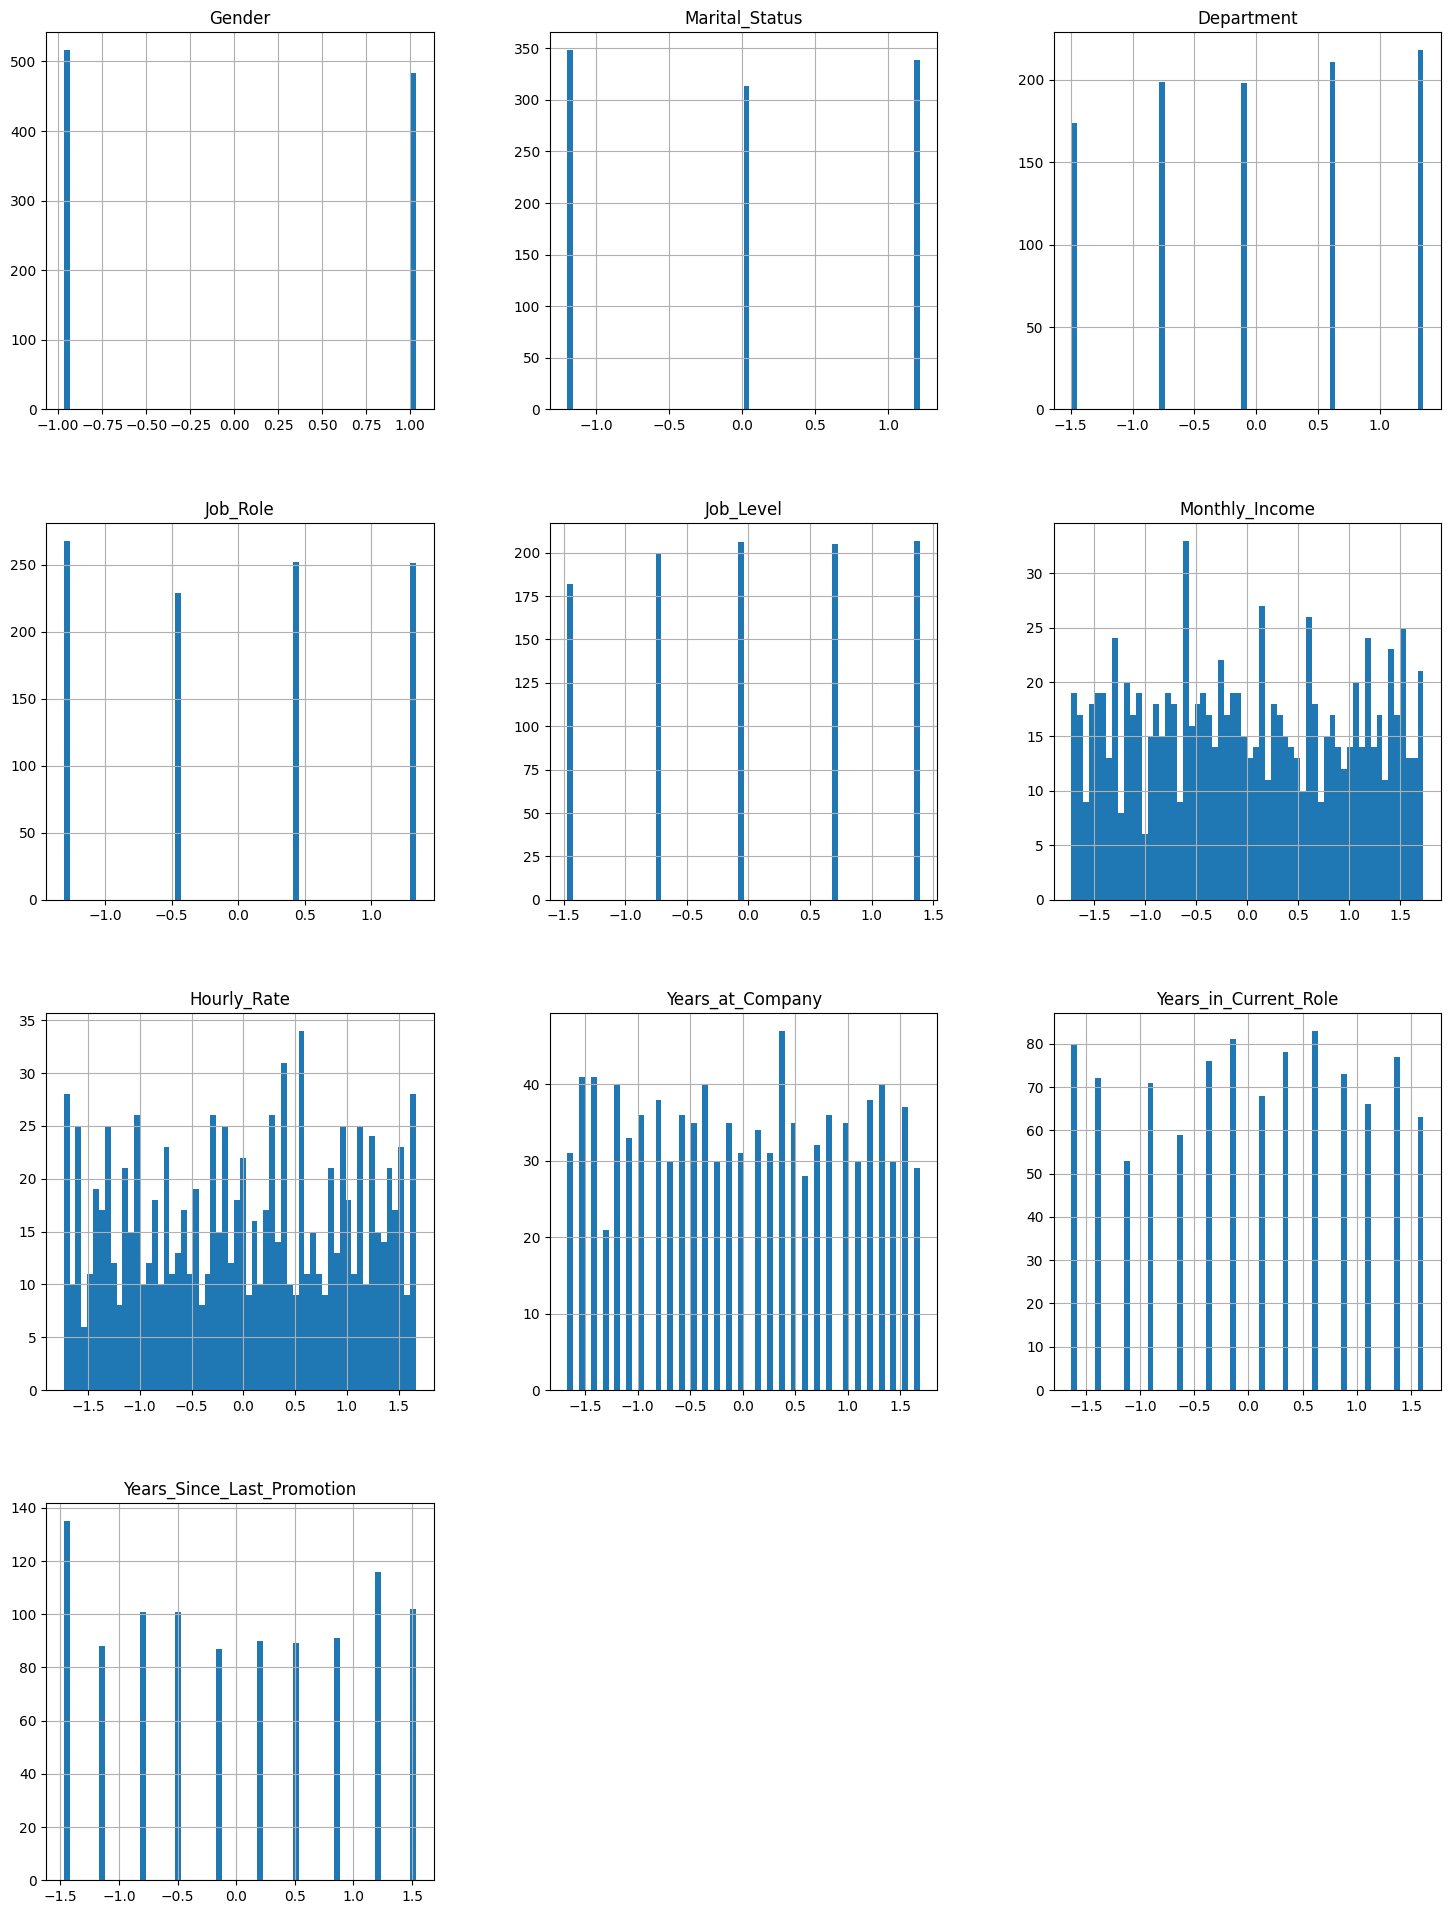

In [77]:
df.hist(bins=60, figsize=(18,24), grid=True)
plt.show()

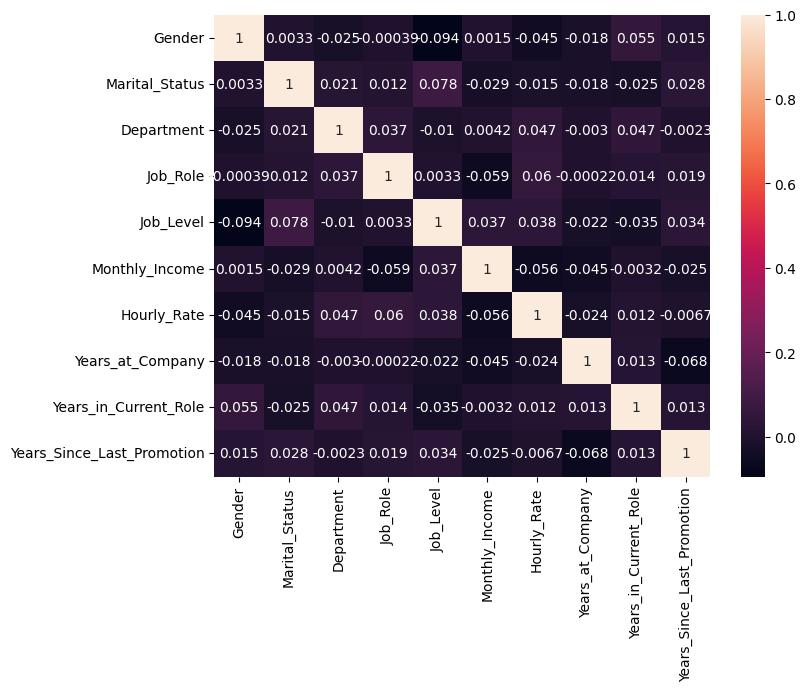

In [78]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [79]:
import umap
features = dfCopy[
    [    
    "Gender",
    "Marital_Status",
    "Job_Role",
    "Job_Level",
    "Monthly_Income",	
    "Hourly_Rate",
    "Years_at_Company",
    "Years_in_Current_Role",
    "Years_Since_Last_Promotion"
    ]
].values
scaled_data = StandardScaler().fit_transform(features)
emb = PCA(n_components=2).fit_transform(scaled_data)
emb.shape

(1000, 2)

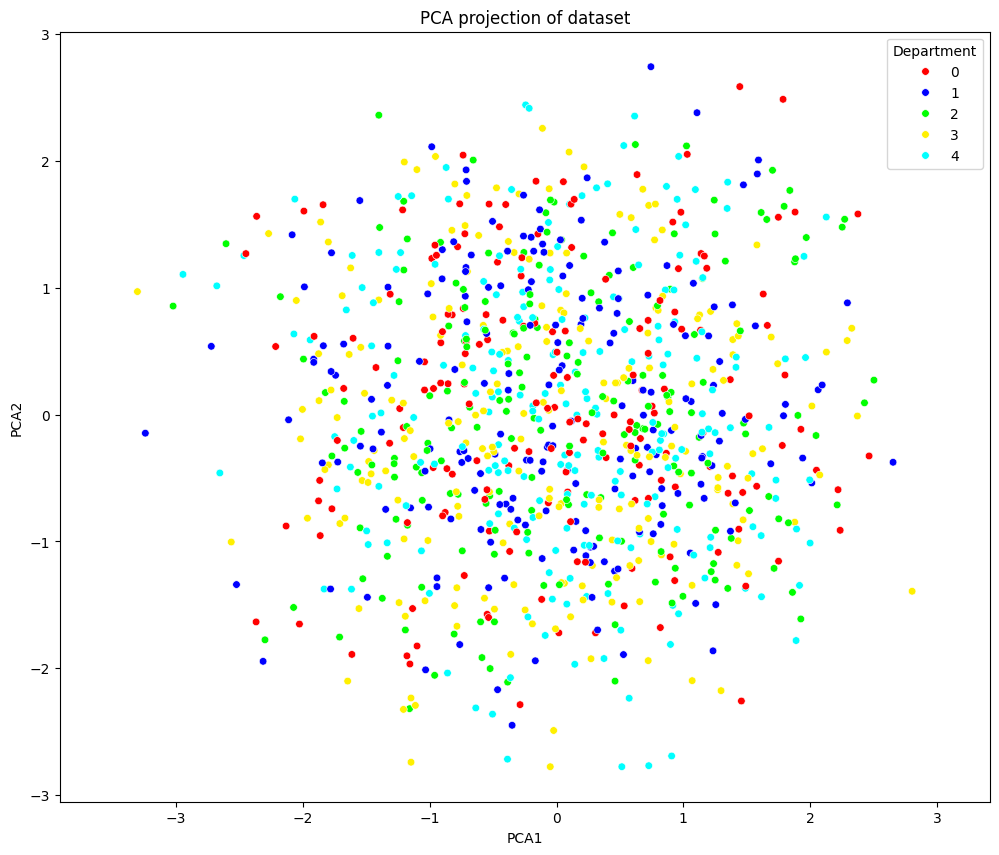

In [80]:
custom_palette = ["#FF0000", "#0000FF", "#00FF00", "#FFF000", "#00FFFF"]
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=emb[:, 0], y=emb[:, 1],
    palette=custom_palette,
    hue=dfCopy.Department,
    s=30
)

plt.gca().set_aspect("equal", "datalim")
#plt.legend(title="SES", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
#plt.title("UMAP projection of dataset")
plt.title("PCA projection of dataset")
plt.show()

<Figure size 1000x1000 with 0 Axes>

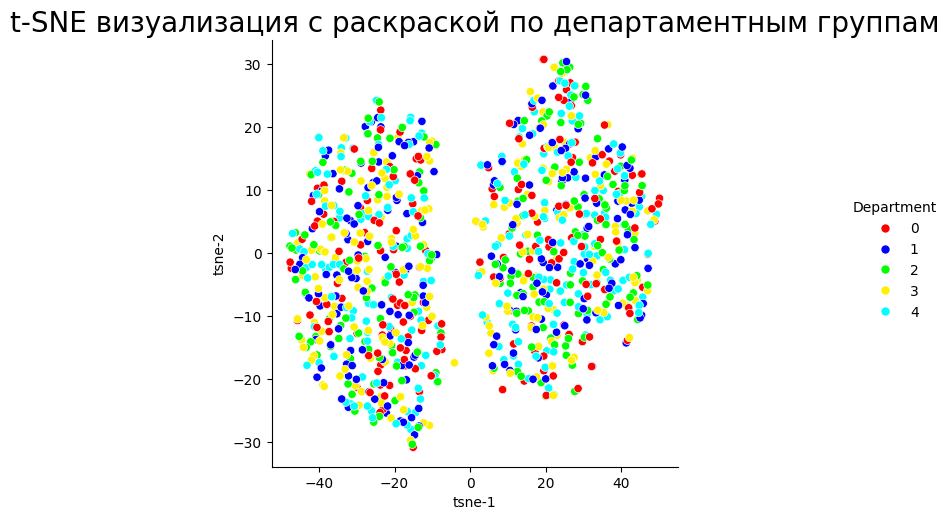

In [81]:
subsetLen = len(df)
subsetDf = df[:subsetLen]

tSNEModel = TSNE()
tSNEData = tSNEModel.fit_transform(scaled_data)

tSNEDf = pd.DataFrame()
tSNEDf['tsne-1'] = tSNEData[:, 0]
tSNEDf['tsne-2'] = tSNEData[:, 1]
tSNEDf['Department'] = dfCopy["Department"]


plt.figure(figsize=(10, 10))
sns.relplot(x='tsne-1', y='tsne-2', palette=custom_palette, hue=dfCopy.Department, data=tSNEDf)
plt.title("t-SNE визуализация с раскраской по департаментным группам", fontsize=20)
plt.show()

/var/folders/z9/t2l4g6sx6ndc0v3qfwnb9v0m0000gn/T/ipykernel_1500/2699952878.py:5: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.scatterplot(


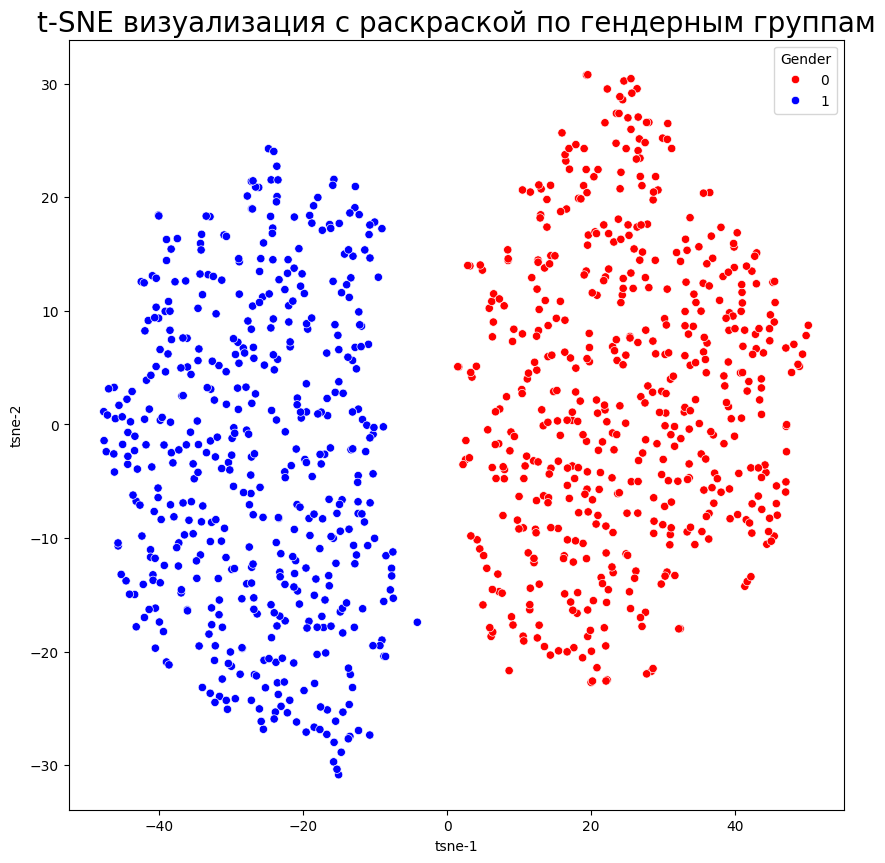

In [82]:
dfCopy['Gender_Group'] = pd.cut(dfCopy['Gender'], bins=[0, 0.5, 1], labels=['Male', 'Female'])
tSNEDf['Gender_Group'] = dfCopy['Gender_Group']
plt.figure(figsize=(10, 10))

sns.scatterplot(
    x='tsne-1',
    y='tsne-2',
    hue= dfCopy.Gender,
    # hue='Gender_Group',
    palette=custom_palette,
    data=tSNEDf
)
plt.title("t-SNE визуализация с раскраской по гендерным группам", fontsize=20)
plt.show()

/Users/matvey_agarkov/Desktop/fuzzy_neuro/.venv/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


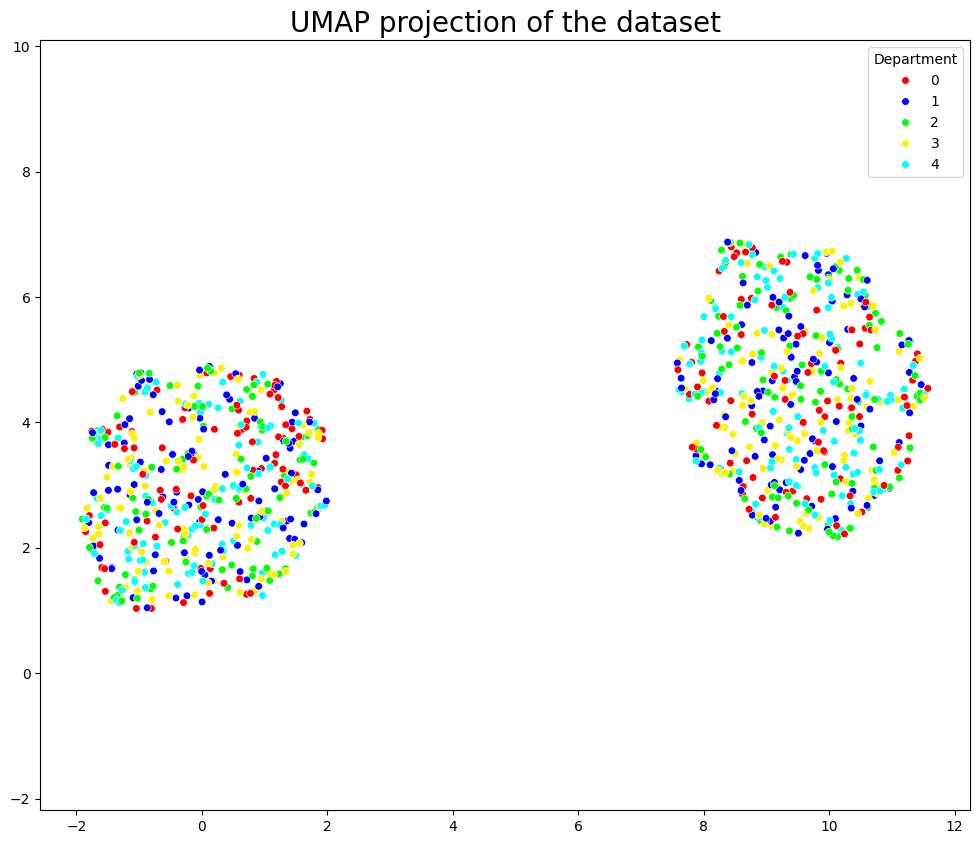

In [83]:
model = umap.UMAP().fit_transform(scaled_data)
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x=model[:, 0], y=model[:, 1],
    palette=custom_palette,
    hue=dfCopy.Department,
    s=30
)
plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset', fontsize=20)
plt.show()